# Linear Discriminant Analysis (LDA) from Scratch

This notebook shows how to implement LDA manually in NumPy without using a built-in LDA function from scikit-learn or any other machine learning library.

The goal of LDA is to find a projection that keeps points from the same class close together while pushing points from different classes farther apart. In other words, it tries to maximize between-class separation and minimize within-class spread.

The key matrices are:

- S_W: within-class scatter matrix
- S_B: between-class scatter matrix
- Eigenvectors: discriminant directions
- Eigenvalues: how strong each direction is for separating classes

We will go through each step clearly and then visualize the transformed data.


Classes: [0 1 2]
Original data shape: (180, 2)
Mean of class 0: [1.87496321 1.96669868]
Mean of class 1: [-0.03932247  5.188051  ]
Mean of class 2: [-2.36143339  0.88096391]
Overall mean: [-0.17526422  2.67857119]
Within-class scatter matrix S_W:
 [[153.56591649   1.7737286 ]
 [  1.7737286  165.14382575]]
Between-class scatter matrix S_B:
 [[540.07490085 168.69096803]
 [168.69096803 602.13859948]]
Eigenvalues: [4.59173225 2.5485964 ]
Eigenvectors:
 [[-0.69724084 -0.74117139]
 [-0.71683695  0.67131585]]
Selected projection matrix W:
 [[-0.69724084 -0.74117139]
 [-0.71683695  0.67131585]]
Reduced feature matrix shape: (180, 2)
First 5 reduced samples:
 [[-3.07537201 -0.6006804 ]
 [-4.37151455  0.40267481]
 [-2.49705626 -0.12334314]
 [-4.47937282 -0.79498732]
 [-2.88974595  0.57247907]]


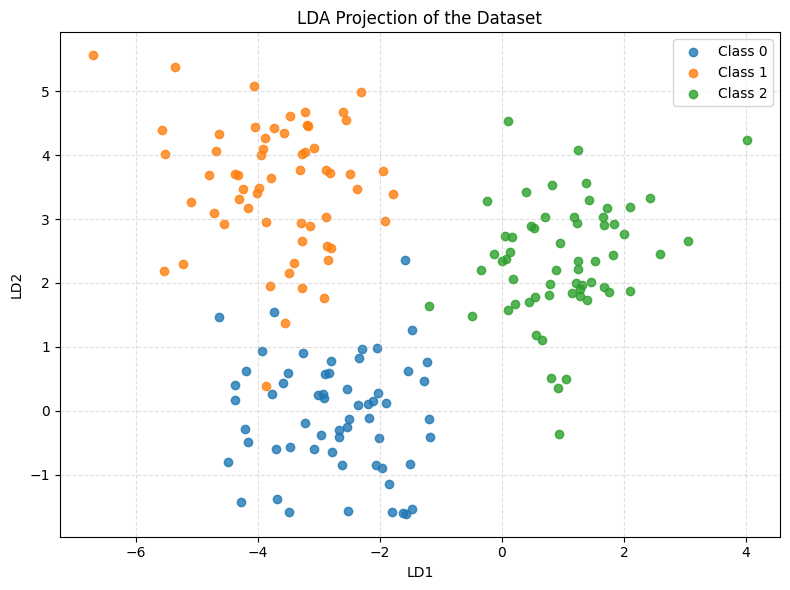

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Step 1: Generate a small example dataset
# ---------------------------------------------------------------
# We create a simple 3-class dataset in 2D so that the reduced LDA
# projection can be displayed clearly on a 2D scatter plot.
np.random.seed(42)
class_1 = np.random.randn(60, 2) + np.array([2.0, 2.0])
class_2 = np.random.randn(60, 2) + np.array([0.0, 5.0])
class_3 = np.random.randn(60, 2) + np.array([-2.5, 1.0])

X = np.vstack([class_1, class_2, class_3])
y = np.array([0] * 60 + [1] * 60 + [2] * 60)
classes = np.unique(y)

print("Classes:", classes)
print("Original data shape:", X.shape)

# ---------------------------------------------------------------
# Step 2: Compute class-wise means and the overall mean
# ---------------------------------------------------------------
# For every class, we calculate the mean vector. This tells us the
# center of each class in feature space.
# The overall mean is the average of all samples across all classes.
# These values are important because LDA compares class centers to the
# global center when measuring separation.
class_means = []
for c in classes:
    X_c = X[y == c]
    mean_c = X_c.mean(axis=0)
    class_means.append(mean_c)
    print(f"Mean of class {c}: {mean_c}")

class_means = np.array(class_means)
overall_mean = X.mean(axis=0)
print("Overall mean:", overall_mean)

# ---------------------------------------------------------------
# Step 3: Construct the Within-Class Scatter Matrix S_W
# ---------------------------------------------------------------
# S_W measures how spread out the samples are within each class.
# If the within-class spread is small, the samples of each class stay
# close to their own class mean.
#
# Formula:
# S_W = sum_c sum_{x in class c} (x - mean_c)(x - mean_c)^T
n_features = X.shape[1]
S_W = np.zeros((n_features, n_features), dtype=float)

for c in classes:
    X_c = X[y == c]
    mean_c = class_means[np.where(classes == c)[0][0]]
    centered = X_c - mean_c
    S_W += centered.T @ centered

print("Within-class scatter matrix S_W:\n", S_W)

# ---------------------------------------------------------------
# Step 4: Construct the Between-Class Scatter Matrix S_B
# ---------------------------------------------------------------
# S_B measures how far the class means are from the overall mean.
# Large separation between class centers means the classes are easier to
# distinguish.
#
# Formula:
# S_B = sum_c N_c (mean_c - overall_mean)(mean_c - overall_mean)^T
S_B = np.zeros((n_features, n_features), dtype=float)

for c in classes:
    X_c = X[y == c]
    mean_c = class_means[np.where(classes == c)[0][0]]
    n_c = X_c.shape[0]
    diff = mean_c - overall_mean
    S_B += n_c * np.outer(diff, diff)

print("Between-class scatter matrix S_B:\n", S_B)

# ---------------------------------------------------------------
# Step 5: Solve the generalized eigenvalue problem for S_W^{-1} S_B
# ---------------------------------------------------------------
# LDA looks for projection directions w that maximize class separability.
# This is done by solving:
#     S_B w = lambda S_W w
# which is the generalized eigenvalue problem.
#
# In practice, we use a numerically stable version by solving:
#     (S_W + eps I)^{-1} S_B
# Then we compute the eigenvalues and eigenvectors.
# The eigenvectors corresponding to the largest eigenvalues are the most
# discriminative directions.
reg = 1e-6
A = np.linalg.solve(S_W + reg * np.eye(n_features), S_B)
eigenvalues, eigenvectors = np.linalg.eig(A)

# Sort eigenvalues in descending order
idx = np.argsort(eigenvalues.real)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

# ---------------------------------------------------------------
# Step 6: Select the top discriminant vectors
# ---------------------------------------------------------------
# The number of useful LDA directions is at most C - 1, where C is the
# number of classes. We choose the vectors associated with the largest
# eigenvalues.
num_classes = len(classes)
k = min(num_classes - 1, n_features)
W = eigenvectors[:, :k]

print("Selected projection matrix W:\n", W)

# ---------------------------------------------------------------
# Step 7: Project the dataset into the new subspace
# ---------------------------------------------------------------
# The projected data is:
#     X_lda = X @ W
# Each sample is transformed into a reduced feature space.
X_lda = X @ W
print("Reduced feature matrix shape:", X_lda.shape)
print("First 5 reduced samples:\n", X_lda[:5])

# ---------------------------------------------------------------
# Step 8: Visualize the projected data
# ---------------------------------------------------------------
# Because the reduced dimension is 2 in this example, we can plot LD1 vs LD2.
# The classes should appear more separated than in the original feature space.
plt.figure(figsize=(8, 6))
for label in classes:
    idx = y == label
    plt.scatter(X_lda[idx, 0], X_lda[idx, 1], label=f"Class {label}", alpha=0.8)

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection of the Dataset")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Final explanation
# ---------------------------------------------------------------
# LDA maximizes class separability by selecting directions that do two things:
# 1. Keep samples within the same class close together (small S_W)
# 2. Push class means far apart from the overall mean (large S_B)
#
# The eigenvalues tell us how strong each discriminant direction is.
# Larger eigenvalues correspond to directions that separate classes better.
# The eigenvectors define the axes of the new lower-dimensional space.
# Projecting the data onto these directions gives us a compact representation
# where classes are easier to distinguish.
